In [23]:
# Скачивание дополнительных пакетов
%pip install -q transformers accelerate bitsandbytes torch sentence-transformers faiss-cpu pandas numpy seaborn
%pip install implicit
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch
import json
import re
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from implicit.als import AlternatingLeastSquares
import joblib
import pickle
import os

# Датасет можно скачать дополнительно тут:
# https://www.kaggle.com/datasets/zygmunt/goodbooks-10k/data

# Пути к файлам
# DATA_PATH = "data\edited"
DATA_PATH = "..\data"
# DATA_PATH = "/content"
ratings = pd.read_csv(f"{DATA_PATH}/ratings.csv")
books = pd.read_csv(f"{DATA_PATH}/books.csv")
to_read = pd.read_csv(f"{DATA_PATH}/to_read.csv")
tags = pd.read_csv(f"{DATA_PATH}/tags.csv")
book_tags = pd.read_csv(f"{DATA_PATH}/book_tags.csv")

print("Данные загружены\n")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Данные загружены



Базовые проверки датасетов

In [24]:
def inspect_df(name, df):
    print(f"---- {name} ----")
    # Размерность
    print(f"Размерность: {df.shape}")
    # Названия колонок
    print("\nСтолбцы:")
    print(list(df.columns))
    # Типы данных
    print("\nТип данных:")
    print(df.dtypes)
    # Общая информация
    print("\nИнформация:")
    df.info()
    # Первые строки
    print("\n:Пример")
    print(df.head())
    print("\n" + "-"*50 + "\n")


# Проверка всех файлов
inspect_df("ratings", ratings)
inspect_df("books", books)
inspect_df("to_read", to_read)
inspect_df("tags", tags)
inspect_df("book_tags", book_tags)

---- ratings ----
Размерность: (5976479, 3)

Столбцы:
['user_id', 'book_id', 'rating']

Тип данных:
user_id    int64
book_id    int64
rating     int64
dtype: object

Информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5976479 entries, 0 to 5976478
Data columns (total 3 columns):
 #   Column   Dtype
---  ------   -----
 0   user_id  int64
 1   book_id  int64
 2   rating   int64
dtypes: int64(3)
memory usage: 136.8 MB

:Пример
   user_id  book_id  rating
0        1      258       5
1        2     4081       4
2        2      260       5
3        2     9296       5
4        2     2318       3

--------------------------------------------------

---- books ----
Размерность: (10000, 23)

Столбцы:
['book_id', 'goodreads_book_id', 'best_book_id', 'work_id', 'books_count', 'isbn', 'isbn13', 'authors', 'original_publication_year', 'original_title', 'title', 'language_code', 'average_rating', 'ratings_count', 'work_ratings_count', 'work_text_reviews_count', 'ratings_1', 'ratings_2', 'r

In [25]:
# Функция проверки на NaN
def check_nan(name, df):
    print(f"---- Проверка на NaN: {name} ----")
    nan_counts = df.isnull().sum()
    nan_percent = (nan_counts / len(df)) * 100

    result = pd.DataFrame({
        "NaN_count": nan_counts,
        "NaN_%": nan_percent.round(2)
    })

    print(result[result["NaN_count"] > 0])
    print("\n")


# Функция проверки дубликатов
def check_duplicates(name, df, subset=None):
    print(f"---- Проверка дубликатов: {name} ----")

    total_dups = df.duplicated().sum()
    print(f"Полные дубликаты: {total_dups}")

    if subset:
        subset_dups = df.duplicated(subset=subset).sum()
        print(f"Дубликаты по ключу {subset}: {subset_dups}")

    print("\n")


# Функция проверки типов
def check_dtypes(name, df):
    print(f"---- Проверка типов данных: {name} ----")
    print(df.dtypes)

    # Дополнительные логические проверки
    if "rating" in df.columns:
        invalid_ratings = df[~df["rating"].between(1, 5)]
        print(f"\nНекорректные rating: {len(invalid_ratings)}")

    if "user_id" in df.columns:
        negative_users = (df["user_id"] <= 0).sum()
        print(f"user_id <= 0: {negative_users}")

    if "book_id" in df.columns:
        negative_books = (df["book_id"] <= 0).sum()
        print(f"book_id <= 0: {negative_books}")

    print("\n")

# ПРОВЕРКИ

# NaN
check_nan("ratings", ratings)
check_nan("books", books)
check_nan("to_read", to_read)
check_nan("tags", tags)
check_nan("book_tags", book_tags)

# Дубликаты
check_duplicates("ratings", ratings, subset=["user_id", "book_id"])
check_duplicates("books", books, subset=["book_id"])
check_duplicates("to_read", to_read, subset=["user_id", "book_id"])
check_duplicates("tags", tags, subset=["tag_id"])
check_duplicates("book_tags", book_tags, subset=["goodreads_book_id", "tag_id"])

# Типы
check_dtypes("ratings", ratings)
check_dtypes("books", books)
check_dtypes("to_read", to_read)
check_dtypes("tags", tags)
check_dtypes("book_tags", book_tags)

---- Проверка на NaN: ratings ----
Empty DataFrame
Columns: [NaN_count, NaN_%]
Index: []


---- Проверка на NaN: books ----
                           NaN_count  NaN_%
isbn                             700   7.00
isbn13                           585   5.85
original_publication_year         21   0.21
original_title                   585   5.85
language_code                   1084  10.84


---- Проверка на NaN: to_read ----
Empty DataFrame
Columns: [NaN_count, NaN_%]
Index: []


---- Проверка на NaN: tags ----
Empty DataFrame
Columns: [NaN_count, NaN_%]
Index: []


---- Проверка на NaN: book_tags ----
Empty DataFrame
Columns: [NaN_count, NaN_%]
Index: []


---- Проверка дубликатов: ratings ----
Полные дубликаты: 0
Дубликаты по ключу ['user_id', 'book_id']: 0


---- Проверка дубликатов: books ----
Полные дубликаты: 0
Дубликаты по ключу ['book_id']: 0


---- Проверка дубликатов: to_read ----
Полные дубликаты: 0
Дубликаты по ключу ['user_id', 'book_id']: 0


---- Проверка дубликатов: tags --

Проверки на согласованность ID между датасетами

In [26]:
print("---- Проверка: все ли book_id из ratings.csv есть в books.csv ----")

ratings_book_ids = set(ratings["book_id"].unique())
books_book_ids = set(books["book_id"].unique())

missing_books = ratings_book_ids - books_book_ids

print(f"Книг в ratings: {len(ratings_book_ids)}")
print(f"Книг в books: {len(books_book_ids)}")
print(f"Отсутствуют в books: {len(missing_books)}")

# Пример проблемных ID
print("Пример:", list(missing_books)[:10])

---- Проверка: все ли book_id из ratings.csv есть в books.csv ----
Книг в ratings: 10000
Книг в books: 10000
Отсутствуют в books: 0
Пример: []


In [27]:
print("---- Проверка: все ли book_id из to_read.csv есть в books.csv ----")

to_read_book_ids = set(to_read["book_id"].unique())

missing_books_tr = to_read_book_ids - books_book_ids

print(f"Книг в to_read: {len(to_read_book_ids)}")
print(f"Отсутствуют в books: {len(missing_books_tr)}")

print("Пример:", list(missing_books_tr)[:10])

---- Проверка: все ли book_id из to_read.csv есть в books.csv ----
Книг в to_read: 9986
Отсутствуют в books: 0
Пример: []


In [28]:
print("---- Проверка: согласованность пользователей ----")

ratings_users = set(ratings["user_id"].unique())
to_read_users = set(to_read["user_id"].unique())

missing_users = to_read_users - ratings_users

print(f"Пользователей в ratings: {len(ratings_users)}")
print(f"Пользователей в to_read: {len(to_read_users)}")
print(f"Пользователи только в to_read: {len(missing_users)}")

print("Пример:", list(missing_users)[:10])

---- Проверка: согласованность пользователей ----
Пользователей в ratings: 53424
Пользователей в to_read: 48871
Пользователи только в to_read: 0
Пример: []


In [29]:
print("---- Проверка: все ли goodreads_book_id из book_tags.csv есть в books.csv ----")

books_gr_ids = set(books["goodreads_book_id"].unique())
book_tags_ids = set(book_tags["goodreads_book_id"].unique())

missing_gr = book_tags_ids - books_gr_ids

print(f"ID в book_tags: {len(book_tags_ids)}")
print(f"Отсутствуют в books: {len(missing_gr)}")

print("Пример:", list(missing_gr)[:10])

---- Проверка: все ли goodreads_book_id из book_tags.csv есть в books.csv ----
ID в book_tags: 10000
Отсутствуют в books: 0
Пример: []


In [30]:
print("---- Проверка: все ли tag_id в book_tags.csv есть в tags.csv ----")

tags_ids = set(tags["tag_id"].unique())
book_tags_tag_ids = set(book_tags["tag_id"].unique())

missing_tags = book_tags_tag_ids - tags_ids

print(f"tag_id в book_tags: {len(book_tags_tag_ids)}")
print(f"Отсутствуют в tags: {len(missing_tags)}")

print("Пример:", list(missing_tags)[:10])

---- Проверка: все ли tag_id в book_tags.csv есть в tags.csv ----
tag_id в book_tags: 34252
Отсутствуют в tags: 0
Пример: []


In [31]:
print("---- Проверка: корректность соответствия book_id и goodreads_book_id ----")

# Создаем mapping
mapping = books[["book_id", "goodreads_book_id"]]

# Проверка уникальности
dup_book_id = mapping["book_id"].duplicated().sum()
dup_gr_id = mapping["goodreads_book_id"].duplicated().sum()

print(f"Дубликаты book_id: {dup_book_id}")
print(f"Дубликаты goodreads_book_id: {dup_gr_id}")

---- Проверка: корректность соответствия book_id и goodreads_book_id ----
Дубликаты book_id: 0
Дубликаты goodreads_book_id: 0


In [32]:
print("---- Очистка данных ----")

# Инициализация
init = {
    "ratings": len(ratings),
    "books": len(books),
    "to_read": len(to_read),
    "book_tags": len(book_tags),
    "tags": len(tags)
}

# Удаление дубликатов
ratings = ratings.drop_duplicates()
books = books.drop_duplicates(subset="book_id")
to_read = to_read.drop_duplicates()
book_tags = book_tags.drop_duplicates()

print("Дубликаты удалены:")
print(f"ratings: {init['ratings'] - len(ratings)}")
print(f"books: {init['books'] - len(books)}")
print(f"to_read: {init['to_read'] - len(to_read)}")
print(f"book_tags: {init['book_tags'] - len(book_tags)}")

# Обновление базовых размеров после удаления дубликатов
init = {k: len(v) for k, v in {
    "ratings": ratings,
    "books": books,
    "to_read": to_read,
    "book_tags": book_tags,
    "tags": tags
}.items()}

# Обработка пропущенных значений
ratings = ratings.dropna(subset=["user_id", "book_id", "rating"])
books = books.dropna(subset=["book_id", "title", "authors"])

if "language_code" in books.columns:
    books["language_code"] = books["language_code"].fillna("unknown")

print("Пропуски обработаны")

# Проверка и стандартизация имени столбца goodreads_book_id
if "goodreads_book_id" not in book_tags.columns:
    possible = [c for c in book_tags.columns if "goodread" in c.lower()]
    if len(possible) == 0:
        raise ValueError("Не найден goodreads_book_id в book_tags")
    book_tags = book_tags.rename(columns={possible[0]: "goodreads_book_id"})

if "goodreads_book_id" not in books.columns:
    raise ValueError("books не содержит goodreads_book_id")

# Объединение таблиц для сопоставления goodreads_book_id и book_id
book_tags = book_tags.merge(
    books[["book_id", "goodreads_book_id"]],
    on="goodreads_book_id",
    how="inner"
)

print(f"book_tags после merge: {init['book_tags'] - len(book_tags)} удалено")

init["book_tags"] = len(book_tags)

# Удаление записей с несуществующими внешними ключами
valid_book_ids = set(books["book_id"])
valid_user_ids = set(ratings["user_id"])
valid_tag_ids = set(tags["tag_id"])

before = len(ratings)
ratings = ratings[ratings["book_id"].isin(valid_book_ids)]
print(f"ratings сломанные книги: {before - len(ratings)}")

before = len(to_read)
to_read = to_read[to_read["book_id"].isin(valid_book_ids)]
to_read = to_read[to_read["user_id"].isin(valid_user_ids)]
print(f"to_read сломанные связи: {before - len(to_read)}")

before = len(book_tags)
book_tags = book_tags[book_tags["book_id"].isin(valid_book_ids)]
book_tags = book_tags[book_tags["tag_id"].isin(valid_tag_ids)]
print(f"book_tags сломанные связи: {before - len(book_tags)}")

# Фильтрация по активности пользователей
user_counts = ratings["user_id"].value_counts()
active_users = user_counts[user_counts >= 5].index

before = len(ratings)
ratings = ratings[ratings["user_id"].isin(active_users)]
print(f"ratings неактивные пользователи: {before - len(ratings)}")

before = len(to_read)
to_read = to_read[to_read["user_id"].isin(active_users)]
print(f"to_read неактивные пользователи: {before - len(to_read)}")

print(f"Активных пользователей: {len(active_users)}")

# Фильтрация по популярности книг
book_counts = ratings["book_id"].value_counts()
popular_books = book_counts[book_counts >= 10].index

before = len(ratings)
ratings = ratings[ratings["book_id"].isin(popular_books)]
print(f"ratings редкие книги: {before - len(ratings)}")

before = len(books)
books = books[books["book_id"].isin(popular_books)]
print(f"books редкие книги: {before - len(books)}")

before = len(to_read)
to_read = to_read[to_read["book_id"].isin(popular_books)]
print(f"to_read редкие книги: {before - len(to_read)}")

before = len(book_tags)
book_tags = book_tags[book_tags["book_id"].isin(popular_books)]
print(f"book_tags редкие книги: {before - len(book_tags)}")

print(f"Популярных книг: {len(popular_books)}")

# Фильтрация по частоте использования тегов
tag_counts = book_tags["tag_id"].value_counts()
popular_tags = tag_counts[tag_counts > 100].index

before = len(book_tags)
book_tags = book_tags[book_tags["tag_id"].isin(popular_tags)]
print(f"book_tags редкие теги: {before - len(book_tags)}")

print(f"Популярных тегов: {len(popular_tags)}")

# Приведение типов данных
ratings["user_id"] = ratings["user_id"].astype(int)
ratings["book_id"] = ratings["book_id"].astype(int)
ratings["rating"] = ratings["rating"].astype(float)
books["book_id"] = books["book_id"].astype(int)
book_tags["book_id"] = book_tags["book_id"].astype(int)

print("Типы данных нормализованы")

# Очистка текстовых полей
books["title"] = books["title"].astype(str).str.strip()
books["authors"] = books["authors"].astype(str).str.strip()

print("Текст очищен")

# Итоговая статистика
print("\n---- ИТОГ ----")
print(f"ratings: {len(ratings)}")
print(f"books: {len(books)}")
print(f"to_read: {len(to_read)}")
print(f"book_tags: {len(book_tags)}")
print(f"tags: {len(tags)}")

---- Очистка данных ----
Дубликаты удалены:
ratings: 0
books: 0
to_read: 0
book_tags: 6
Пропуски обработаны
book_tags после merge: 0 удалено
ratings сломанные книги: 0
to_read сломанные связи: 0
book_tags сломанные связи: 0
ratings неактивные пользователи: 0
to_read неактивные пользователи: 0
Активных пользователей: 53424
ratings редкие книги: 8
books редкие книги: 1
to_read редкие книги: 0
book_tags редкие книги: 56
Популярных книг: 9999
book_tags редкие теги: 187164
Популярных тегов: 1100
Типы данных нормализованы
Текст очищен

---- ИТОГ ----
ratings: 5976471
books: 9999
to_read: 912705
book_tags: 812686
tags: 34252


In [33]:
def save_current_plot(filename):
    output_dir = os.path.join('..', 'artifacts')
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(output_dir, filename)
    plt.savefig(path, dpi=300, bbox_inches='tight')

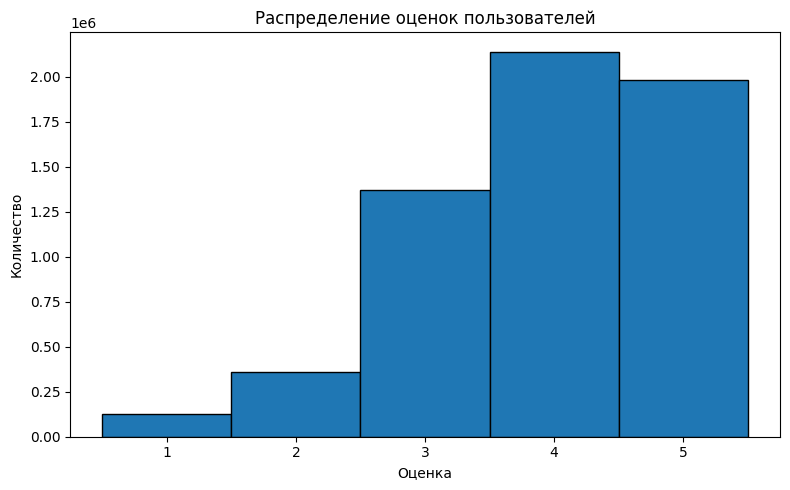

Средняя оценка: 3.92
Медиана: 4.00


In [34]:
# График распределения оценок пользователей
plt.figure(figsize=(8, 5))
plt.hist(ratings['rating'], bins=range(1, 7), edgecolor='black', align='left')
plt.title('Распределение оценок пользователей')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.xticks(range(1, 6))
plt.tight_layout()
save_current_plot("ratings_distribution.png")
plt.show()


print(f"Средняя оценка: {ratings['rating'].mean():.2f}")
print(f"Медиана: {ratings['rating'].median():.2f}")

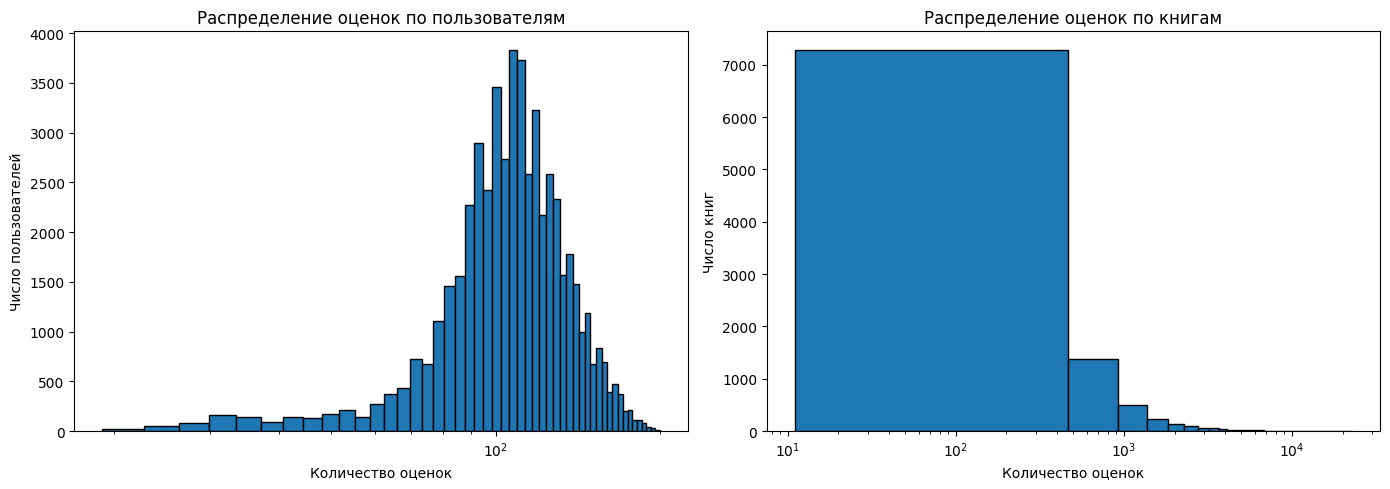

Пользователей: 53424
Книг с оценками: 9999
Среднее количество оценок на пользователя: 111.9
Среднее количество оценок на книгу: 597.7


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Пользователи
user_counts = ratings['user_id'].value_counts()
axes[0].hist(user_counts, bins=50, edgecolor='black')
axes[0].set_title('Распределение оценок по пользователям')
axes[0].set_xlabel('Количество оценок')
axes[0].set_ylabel('Число пользователей')
axes[0].set_xscale('log')

# Книги
book_counts = ratings['book_id'].value_counts()
axes[1].hist(book_counts, bins=50, edgecolor='black')
axes[1].set_title('Распределение оценок по книгам')
axes[1].set_xlabel('Количество оценок')
axes[1].set_ylabel('Число книг')
axes[1].set_xscale('log')

plt.tight_layout()
save_current_plot("user_book_distribution.png")
plt.show()

print(f"Пользователей: {ratings['user_id'].nunique()}")
print(f"Книг с оценками: {ratings['book_id'].nunique()}")
print(f"Среднее количество оценок на пользователя: {user_counts.mean():.1f}")
print(f"Среднее количество оценок на книгу: {book_counts.mean():.1f}")

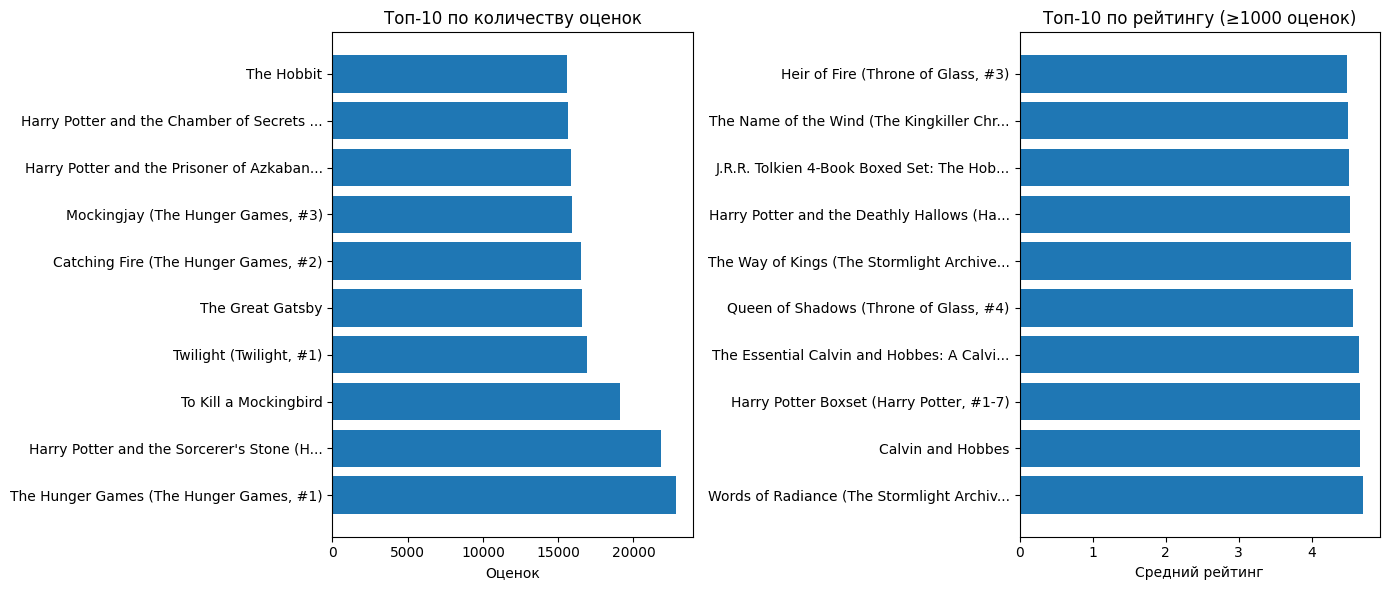

In [36]:
# Подготовка данных
book_stats = ratings.groupby('book_id').agg(
    count=('rating', 'size'),
    avg_rating=('rating', 'mean')
).reset_index()
book_stats = book_stats.merge(books[['book_id', 'title', 'authors']], on='book_id')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# По количеству оценок
top_by_count = book_stats.nlargest(10, 'count')
axes[0].barh(range(10), top_by_count['count'])
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([t[:40]+'...' if len(t)>40 else t for t in top_by_count['title']])
axes[0].set_title('Топ-10 по количеству оценок')
axes[0].set_xlabel('Оценок')

# По среднему рейтингу (минимум 1000 оценок)
qualified = book_stats[book_stats['count'] >= 1000]
top_by_rating = qualified.nlargest(10, 'avg_rating')
axes[1].barh(range(10), top_by_rating['avg_rating'])
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([t[:40]+'...' if len(t)>40 else t for t in top_by_rating['title']])
axes[1].set_title('Топ-10 по рейтингу (≥1000 оценок)')
axes[1].set_xlabel('Средний рейтинг')

plt.tight_layout()
save_current_plot("top_books_analysis.png")
plt.show()

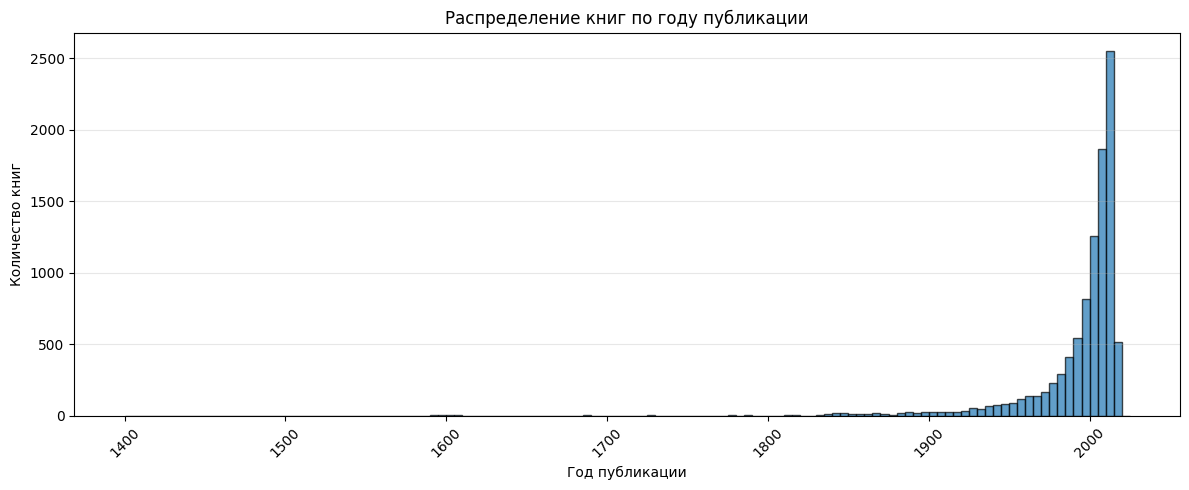

Диапазон: 1418 – 2017
Средний год: 1991
Медиана: 2004


In [37]:
# График распределения книг по году публикации
books_years = books.dropna(subset=['original_publication_year'])
books_years = books_years[books_years['original_publication_year'].between(1400, 2025)]

plt.figure(figsize=(12, 5))
plt.hist(books_years['original_publication_year'],
         bins=range(1400, 2026, 5),  # шаг 5 лет
         edgecolor='black', alpha=0.7)
plt.title('Распределение книг по году публикации')
plt.xlabel('Год публикации')
plt.ylabel('Количество книг')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_current_plot("books_by_year.png")
plt.show()

# Статистика по годам
print(f"Диапазон: {books_years['original_publication_year'].min():.0f} – {books_years['original_publication_year'].max():.0f}")
print(f"Средний год: {books_years['original_publication_year'].mean():.0f}")
print(f"Медиана: {books_years['original_publication_year'].median():.0f}")

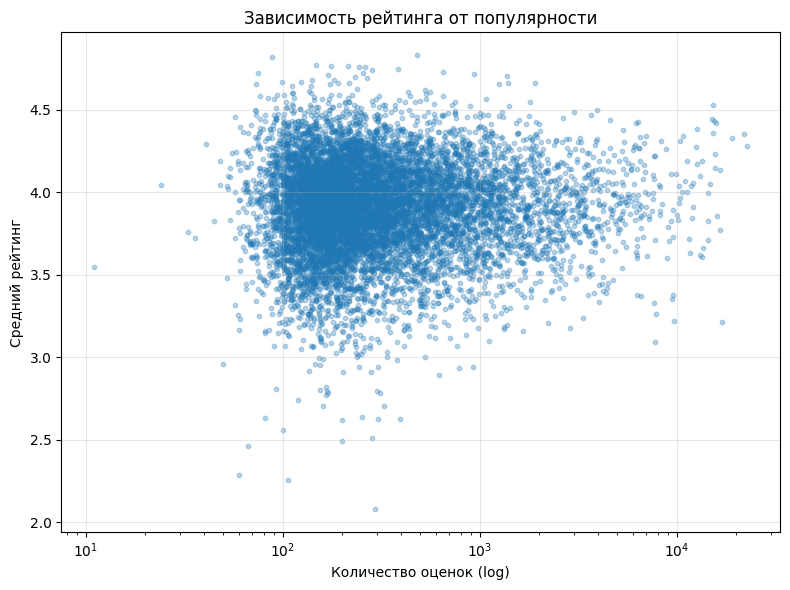

Корреляция Пирсона: 0.028


In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(book_stats['count'], book_stats['avg_rating'], alpha=0.3, s=10)
plt.xscale('log')
plt.xlabel('Количество оценок (log)')
plt.ylabel('Средний рейтинг')
plt.title('Зависимость рейтинга от популярности')
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_current_plot("rating_vs_popularity.png")
plt.show()

# Коэффициент корреляции Пирсона (r) — это статистическая мера,
# определяющая силу и направление линейной связи между двумя количественными переменными.
# Он показывает, насколько пропорционально изменяются величины:
# при увеличении одной переменной вторая также растет или уменьшается по прямой линии.
# Значение коэффициента всегда находится в диапазоне от -1 до 1
corr = book_stats['count'].corr(book_stats['avg_rating'])
print(f"Корреляция Пирсона: {corr:.3f}")

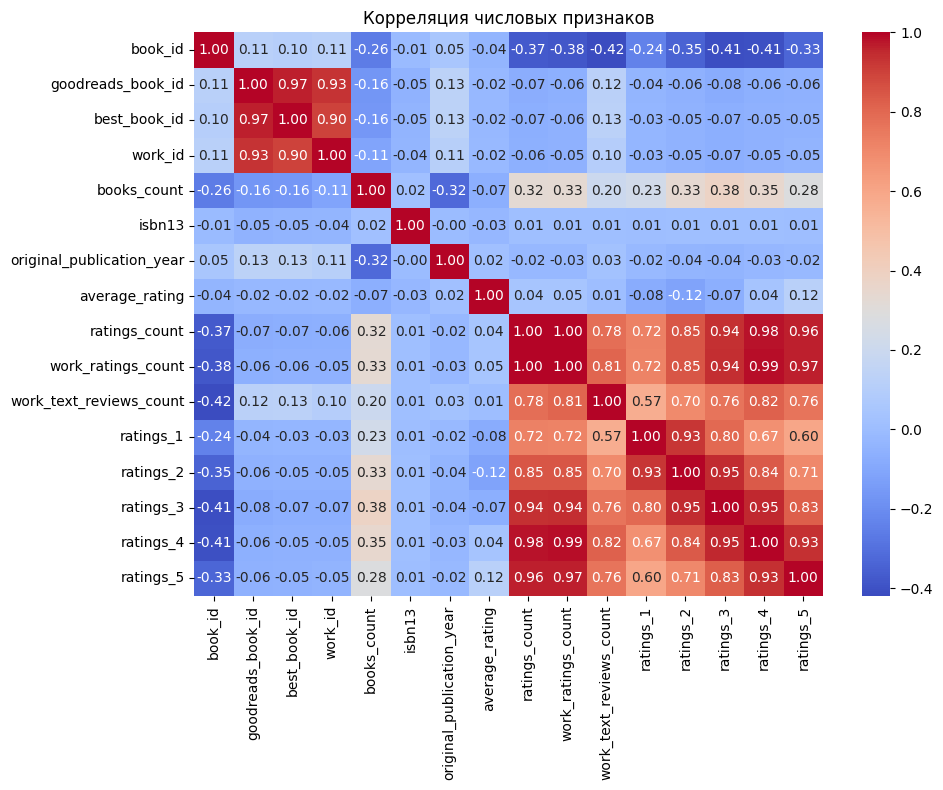

In [39]:
numeric_cols = books.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(books[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция числовых признаков')
plt.tight_layout()
save_current_plot("numeric_correlation.png")
plt.show()

Анализ пользователя: 1
--------------------------------------------------

Базовая статистика:
Всего оценок: 117
Средняя оценка: 3.59
Медиана: 4.0
Стандартное отклонение: 0.96
Мин/Макс оценка: 1.0 / 5.0


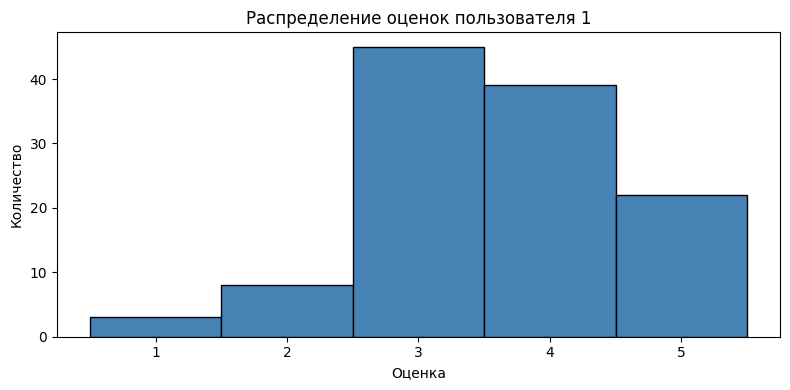


Топ-5 любимых книг (оценка 5):
  • The Shadow of the Wind (The Cemetery of Forgotten ... — Carlos Ruiz Zafón, Lucia Graves
  • Gilead (Gilead, #1) — Marilynne Robinson
  • The Kite Runner — Khaled Hosseini
  • Peace Like a River — Leif Enger
  • Divine Secrets of the Ya-Ya Sisterhood — Rebecca Wells

Топ-5 авторов по количеству книг:
  - John Steinbeck: 3 книг
  - Stieg Larsson, Reg Keeland: 3 книг
  - Geraldine Brooks: 3 книг
  - Elena Ferrante, Ann Goldstein: 3 книг
  - Orson Scott Card: 2 книг

Сравнение с платформой:
Средняя оценка пользователя: 3.59
Средняя оценка по платформе: 3.92
Отклонение: строже на 0.33


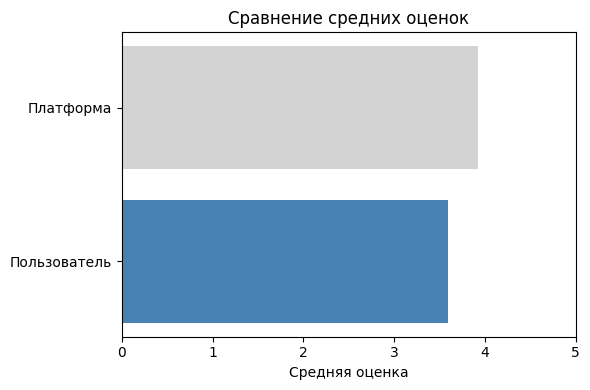


Топ-5 тегов пользователя:
  - to-read: 117 книг
  - favorites: 114 книг
  - owned: 114 книг
  - books-i-own: 113 книг
  - owned-books: 113 книг


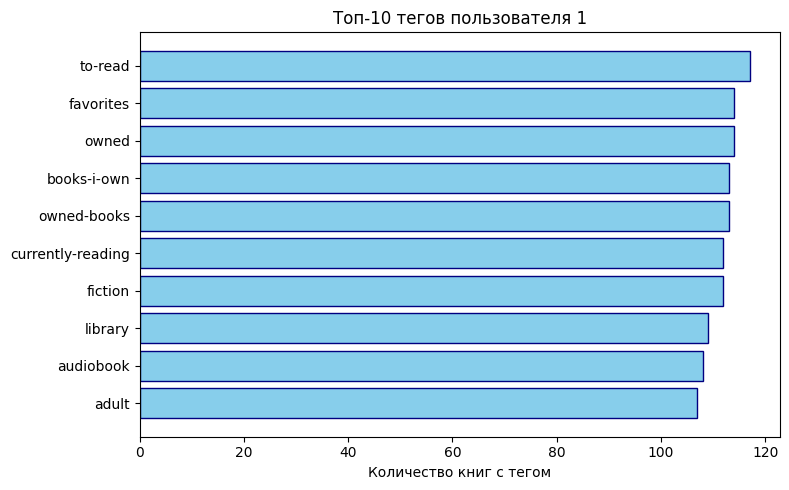

In [40]:
# Выбираем случайного активного пользователя
# np.random.seed(42)  # для воспроизводимости
# random_user = np.random.choice(ratings['user_id'].unique())

# Для теста возьмем конкретного пользователя
random_user = 1

print(f"Анализ пользователя: {random_user}")
print("-" * 50)

# Фильтруем данные пользователя
user_ratings = ratings[ratings['user_id'] == random_user]

# Базовая статистика
print(f"\nБазовая статистика:")
print(f"Всего оценок: {len(user_ratings)}")
print(f"Средняя оценка: {user_ratings['rating'].mean():.2f}")
print(f"Медиана: {user_ratings['rating'].median():.1f}")
print(f"Стандартное отклонение: {user_ratings['rating'].std():.2f}")
print(f"Мин/Макс оценка: {user_ratings['rating'].min():.1f} / {user_ratings['rating'].max():.1f}")

# Распределение оценок пользователя
plt.figure(figsize=(8, 4))
plt.hist(user_ratings['rating'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], edgecolor='black', color='steelblue', align='mid')
plt.xticks(range(1, 6))
plt.title(f'Распределение оценок пользователя {random_user}')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.tight_layout()
save_current_plot(f"user_{random_user}_rating_dist.png")
plt.show()


# Топ-5 любимых книг (оценка 5)
print(f"\nТоп-5 любимых книг (оценка 5):")
top_liked = user_ratings[user_ratings['rating'] == 5.0].merge(
    books[['book_id', 'title', 'authors']], on='book_id'
).head(5)

if len(top_liked) > 0:
    for idx, row in top_liked.iterrows():
        title = row['title'][:50] + '...' if len(row['title']) > 50 else row['title']
        print(f"  • {title} — {row['authors']}")
else:
    print("  Нет книг с оценкой 5")

# Топ-5 авторов по количеству прочитанных книг
print(f"\nТоп-5 авторов по количеству книг:")
user_books = user_ratings.merge(books[['book_id', 'authors']], on='book_id')
author_counts = user_books['authors'].value_counts().head(5)

for author, count in author_counts.items():
    print(f"  - {author}: {count} книг")

# Сравнение с глобальной статистикой
global_avg = ratings['rating'].mean()
user_avg = user_ratings['rating'].mean()
print(f"\nСравнение с платформой:")
print(f"Средняя оценка пользователя: {user_avg:.2f}")
print(f"Средняя оценка по платформе: {global_avg:.2f}")
diff = user_avg - global_avg
if diff > 0:
    print(f"Отклонение: щедрее на {abs(diff):.2f}")
else:
    print(f"Отклонение: строже на {abs(diff):.2f}")

# Визуализация сравнения
plt.figure(figsize=(6, 4))
plt.barh(['Пользователь', 'Платформа'], [user_avg, global_avg], color=['steelblue', 'lightgray'])
plt.xlabel('Средняя оценка')
plt.title('Сравнение средних оценок')
plt.xlim(0, 5)
plt.tight_layout()
save_current_plot(f"user_{random_user}_avg_comparison.png")
plt.show()

# Топ-5 тегов пользователя
print(f"\nТоп-5 тегов пользователя:")
user_book_ids = user_ratings['book_id'].unique()

# Фильтруем book_tags по книгам пользователя
user_tags = book_tags[book_tags['book_id'].isin(user_book_ids)]
user_tags_named = user_tags.merge(tags[['tag_id', 'tag_name']], on='tag_id')

# Считаем количество книг с каждым тегом (не сумму count!)
tag_occurrences = user_tags_named.groupby('tag_name').size().nlargest(5)

if len(tag_occurrences) > 0:
    for tag, count in tag_occurrences.items():
        print(f"  - {tag}: {count} книг")
else:
    print("  Теги не найдены")

# Визуализация топ-10 тегов пользователя
if len(tag_occurrences) > 0:
    plt.figure(figsize=(8, 5))
    top_10_tags = user_tags_named.groupby('tag_name').size().nlargest(10)
    plt.barh(range(len(top_10_tags)), top_10_tags.values, color='skyblue', edgecolor='navy')
    plt.yticks(range(len(top_10_tags)), top_10_tags.index)
    plt.xlabel('Количество книг с тегом')
    plt.title(f'Топ-10 тегов пользователя {random_user}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    save_current_plot(f"user_{random_user}_top_tags.png")
    plt.show()


Сравнение оценок пользователя 1 со средними по платформе
Среднее отклонение: -0.40
Стд. отклонения: 0.89
Макс. отклонение: 3.04


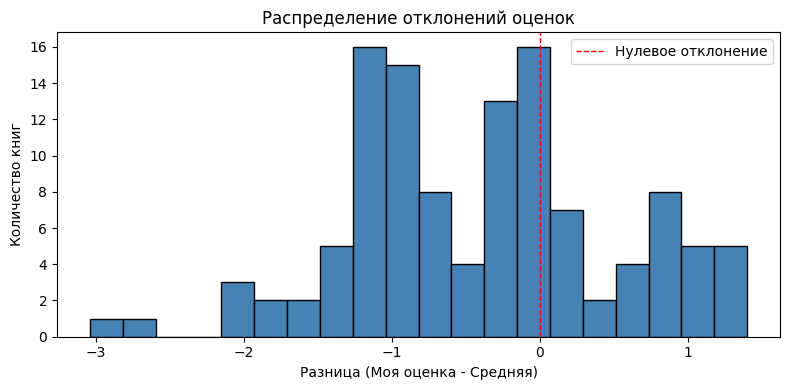


Книги, оценённые выше среднего (Топ-5 по отклонению):
  - Antigone (The Theban Plays, #3)
    Моя оценка: 5.0 | Средняя: 3.60 | Δ: +1.40
  - Divine Secrets of the Ya-Ya Sisterhood
    Моя оценка: 5.0 | Средняя: 3.79 | Δ: +1.21
  - The Paris Wife
    Моя оценка: 5.0 | Средняя: 3.79 | Δ: +1.21
  - Caleb's Crossing
    Моя оценка: 5.0 | Средняя: 3.81 | Δ: +1.19
  - The Alchemist
    Моя оценка: 5.0 | Средняя: 3.82 | Δ: +1.18

Книги, оценённые ниже среднего (Топ-5 по отклонению):
  • One Hundred Years of Solitude
    Моя оценка: 1.0 | Средняя: 4.04 | Δ: -3.04
  • Atlas Shrugged
    Моя оценка: 1.0 | Средняя: 3.68 | Δ: -2.68
  • Angela's Ashes (Frank McCourt, #1)
    Моя оценка: 2.0 | Средняя: 4.07 | Δ: -2.07
  • Speaker for the Dead (Ender's Saga, #2)
    Моя оценка: 2.0 | Средняя: 4.04 | Δ: -2.04
  • The Time Traveler's Wife
    Моя оценка: 2.0 | Средняя: 3.95 | Δ: -1.95

Корреляция Пирсона между моими и средними оценками: 0.376
- Пользователь имеет уникальные предпочтения


In [41]:
# Рейтинг пользователя | Средняя оценка
print(f"\nСравнение оценок пользователя {random_user} со средними по платформе")

# Объединяем оценки пользователя со средними рейтингами книг
user_comparison = user_ratings.merge(
    books[['book_id', 'title', 'average_rating', 'ratings_count']],
    on='book_id'
)

# Статистика отклонений
user_comparison['diff'] = user_comparison['rating'] - user_comparison['average_rating']
print(f"Среднее отклонение: {user_comparison['diff'].mean():+.2f}")
print(f"Стд. отклонения: {user_comparison['diff'].std():.2f}")
print(f"Макс. отклонение: {user_comparison['diff'].abs().max():.2f}")

# Гистограмма разниц
plt.figure(figsize=(8, 4))
plt.hist(user_comparison['diff'], bins=20, edgecolor='black', color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Нулевое отклонение')
plt.xlabel('Разница (Моя оценка - Средняя)')
plt.ylabel('Количество книг')
plt.title('Распределение отклонений оценок')
plt.legend()
plt.tight_layout()
save_current_plot(f"user_{random_user}_rating_diff.png")
plt.show()

# Топ-5 книг, которые пользователь оценил ВЫШЕ среднего
print(f"\nКниги, оценённые выше среднего (Топ-5 по отклонению):")
higher = user_comparison[user_comparison['diff'] > 0].nlargest(5, 'diff')
for _, row in higher.iterrows():
    title = row['title'][:45] + '...' if len(row['title']) > 45 else row['title']
    print(f"  - {title}")
    print(f"    Моя оценка: {row['rating']:.1f} | Средняя: {row['average_rating']:.2f} | Δ: +{row['diff']:.2f}")

# Топ-5 книг, которые пользователь оценил НИЖЕ среднего
print(f"\nКниги, оценённые ниже среднего (Топ-5 по отклонению):")
lower = user_comparison[user_comparison['diff'] < 0].nsmallest(5, 'diff')
for _, row in lower.iterrows():
    title = row['title'][:45] + '...' if len(row['title']) > 45 else row['title']
    print(f"  • {title}")
    print(f"    Моя оценка: {row['rating']:.1f} | Средняя: {row['average_rating']:.2f} | Δ: {row['diff']:.2f}")

# Корреляция
corr = user_comparison['rating'].corr(user_comparison['average_rating'])
print(f"\nКорреляция Пирсона между моими и средними оценками: {corr:.3f}")
if corr > 0.7:
    print("- Вкусы пользователя близки к средним по платформе")
elif corr > 0.4:
    print("- Умеренное совпадение вкусов")
else:
    print("- Пользователь имеет уникальные предпочтения")

In [42]:
# ---- Создание top_tags ----

# merge тегов
book_tags = book_tags.merge(tags, on="tag_id", how="left")

# берём топ-5 тегов по count
top_tags = (
    book_tags.sort_values(["goodreads_book_id", "count"], ascending=[True, False])
    .groupby("goodreads_book_id")["tag_name"]
    .apply(lambda x: ", ".join(x.dropna().astype(str).unique()[:5]))
    .reset_index()
    .rename(columns={"tag_name": "top_tags"})
)

# добавляем в books
books = books.merge(top_tags, on="goodreads_book_id", how="left")

# защита от NaN
books["top_tags"] = books["top_tags"].fillna("")

print("OK, top_tags добавлен")
print(books[["book_id", "top_tags"]].head())

OK, top_tags добавлен
   book_id                                           top_tags
0        1  favorites, currently-reading, young-adult, fic...
1        2  to-read, favorites, fantasy, currently-reading...
2        3      young-adult, fantasy, favorites, vampires, ya
3        4  classics, favorites, to-read, classic, histori...
4        5  classics, favorites, fiction, classic, books-i...


In [43]:
# --- Функции для профиля пользователя и кандидатов ---
def get_user_history(user_id: int) -> pd.DataFrame:
    hist = ratings[ratings["user_id"] == int(user_id)].merge(
        books[[
            "book_id", "title", "authors", "average_rating",
            "ratings_count", "top_tags", "original_publication_year"
        ]],
        on="book_id",
        how="left"
    ).copy()
    return hist.sort_values("rating", ascending=False)

def build_user_profile(user_id: int, liked_threshold=4.0, disliked_threshold=2.0) -> dict:
    hist = get_user_history(user_id)

    liked = hist[hist["rating"] >= liked_threshold].copy()
    disliked = hist[hist["rating"] <= disliked_threshold].copy()

    def split_tags(series):
        out = []
        for x in series.fillna(""):
            if x.strip():
                out.extend([t.strip() for t in x.split(",") if t.strip()])
        return out

    liked_tags = split_tags(liked["top_tags"]) if len(liked) else []
    disliked_tags = split_tags(disliked["top_tags"]) if len(disliked) else []

    favorite_tags = Counter(liked_tags).most_common(12)
    avoid_tags = Counter(disliked_tags).most_common(8)

    profile = {
        "user_id": int(user_id),
        "history_count": int(len(hist)),
        "liked_count": int(len(liked)),
        "disliked_count": int(len(disliked)),
        "mean_rating": float(hist["rating"].mean()) if len(hist) else None,
        "liked_books": liked[["book_id", "title", "authors", "rating"]].head(10).to_dict("records"),
        "disliked_books": disliked[["book_id", "title", "authors", "rating"]].head(5).to_dict("records"),
        "favorite_tags": favorite_tags,
        "avoid_tags": avoid_tags,
        "history_book_ids": set(hist["book_id"].dropna().astype(int).tolist())
    }
    return profile

def build_candidates(profile: dict, n_candidates: int = 20) -> pd.DataFrame:
    user_book_ids = profile["history_book_ids"]

    pool = books[~books["book_id"].isin(user_book_ids)].copy()

    # Популярность и рейтинг
    pool["log_pop"] = np.log1p(pool["ratings_count"].fillna(0))
    pool["pop_norm"] = (pool["log_pop"] - pool["log_pop"].min()) / (pool["log_pop"].max() - pool["log_pop"].min() + 1e-9)
    pool["rating_norm"] = (pool["average_rating"] - pool["average_rating"].min()) / (pool["average_rating"].max() - pool["average_rating"].min() + 1e-9)

    # Оценка пересечения по тегам
    fav_tags = [t for t, _ in profile["favorite_tags"]]
    if fav_tags:
        fav_tag_set = set(fav_tags)
        pool["tag_overlap"] = pool["top_tags"].fillna("").apply(
            lambda x: len(fav_tag_set.intersection({t.strip() for t in x.split(",") if t.strip()}))
        )
        pool["tag_overlap_norm"] = pool["tag_overlap"] / max(len(fav_tag_set), 1)
    else:
        pool["tag_overlap_norm"] = 0.0

    # Итоговый скор для shortlist
    pool["retrieval_score"] = (
        0.45 * pool["tag_overlap_norm"] +
        0.35 * pool["rating_norm"] +
        0.20 * pool["pop_norm"]
    )

    cols = ["book_id", "title", "authors", "average_rating", "ratings_count", "top_tags", "retrieval_score"]
    return pool.sort_values("retrieval_score", ascending=False)[cols].head(n_candidates).reset_index(drop=True)

In [44]:
# --- Загрузка Qwen (для прогноза через промпт) ---

# Выбираем модель
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
# MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
# MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

# Конфигурация
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

print(f"Загрузка модели {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    quantization_config=bnb_config,
    trust_remote_code=True,
)
model.eval()
print("Модель загружена успешно.")

Загрузка модели Qwen/Qwen2.5-1.5B-Instruct...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\bitsandbytes\backends\default\ops.py:223: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\bitsandbytes\backends\cpu\ops.py:36: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 338/338 [01:23<00:00,  4.04it/s]


Модель загружена успешно.


In [45]:
def make_prompt(profile: dict, candidates: pd.DataFrame, n: int = 5) -> list:
    # Формируем блок любимых книг с контекстом
    liked_books_txt = "\n".join(
        [f"- \"{b['title']}\" by {b['authors']} | Rating: {b['rating']:.1f}"
         for b in profile["liked_books"]]
    ) or "- нет данных"

    # Формируем блок нелюбимых книг
    disliked_books_txt = "\n".join(
        [f"- \"{b['title']}\" by {b['authors']} | Rating: {b['rating']:.1f}"
         for b in profile["disliked_books"]]
    ) or "- нет данных"

    # Используем favorite_tags вместо отсутствующего favorite_authors
    fav_tags_txt = ", ".join([f"{t} ({c})" for t, c in profile["favorite_tags"][:8]]) or "- нет данных"

    authors_list = [b['authors'] for b in profile["liked_books"] if b['authors']]
    unique_authors = list(set(authors_list))[:5] # Берем до 5 уникальных авторов
    fav_authors_str = ", ".join(unique_authors) if unique_authors else "Нет данных"

    # Формируем список кандидатов
    cand_lines = []
    for _, row in candidates.iterrows():
        cand_lines.append(
            f"ID:{int(row['book_id'])}. \"{row['title']}\" by {row['authors']} | "
            f"AvgRating:{row['average_rating']:.2f} | Tags:{row['top_tags']}"
        )

    system_msg = (
        "Ты — интеллектуальная система рекомендаций книг. "
        "Твоя задача — выбрать из списка кандидатов книги, которые максимально соответствуют вкусам пользователя. "
        "Анализируй авторов, жанры (теги) и стиль предыдущих высоких оценок пользователя. "
        "Избегай книг, которые стилистически противоречат вкусу пользователя. "
        "Верни строго JSON без пояснений."
    )

    user_msg = f"""
### Профиль пользователя
- Средний рейтинг: {profile["mean_rating"]:.2f}
- Любимые авторы (из истории): {fav_authors_str}
- Ключевые теги интересов: {fav_tags_txt}

### История высоких оценок (Что нравится)
{liked_books_txt}

### История низких оценок (Что НЕ нравится)
{disliked_books_txt}

### Список кандидатов для рекомендации
{chr(10).join(cand_lines)}

### Задача
Выбери top {n} книг из кандидатов.

### Правила выбора
1. **Автор:** Если среди кандидатов есть книги авторов, которые пользователь уже высоко оценивал, отдавай им приоритет.
2. **Жанр/Теги:** Сравнивай теги кандидатов с "Ключевыми тегами интересов" и тегами из "Истории высоких оценок". Ищи пересечения.
3. **Стиль:** Если пользователь любит сложные миры (теги: magic-system, epic, world-building), избегай простых романов.
4. **Исключения:** Не рекомендуй книги, которые пользователь уже читал (их нет в списке кандидатов, но будь внимателен).
5. **Reason:** Напиши причину на русском языке (1-2 предложения). Объясни, почему эта книга подходит, ссылаясь на конкретного автора, похожий жанр или тег из истории пользователя.
6. **Самопроверка:** Проверь, насколько рекомендуемая книга действительно подходит пользователю. Убедись, что похожие книги серии/автора нравятся читателю (оценка не ниже 4). Удели особое внимание тегу favorites.

### Формат ответа (строго JSON)
{{
  "user_id": {profile["user_id"]},
  "recommendations": [
    {{"book_id": 123, "title": "...", "authors": "...", "reason": "..."}},
    ...
  ]
}}
""".strip()

    return [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg}
    ]



def generate_recommendations(user_id: int, n: int = 5, shortlist_size: int = 20, max_new_tokens: int = 1024):
    profile = build_user_profile(user_id)
    candidates = build_candidates(profile, n_candidates=shortlist_size)

    # Если у пользователя совсем нет истории, берем просто популярные/высокорейтинговые книги
    if profile["history_count"] == 0:
        candidates = books.sort_values(["average_rating", "ratings_count"], ascending=False).head(shortlist_size).copy()
        candidates = candidates[["book_id", "title", "authors", "average_rating", "ratings_count", "top_tags"]]
        candidates["retrieval_score"] = 0.0

    messages = make_prompt(profile, candidates, n=n)
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    inputs = tokenizer([prompt], return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.1,
            top_p=1.0,
            repetition_penalty=1.05
        )

    generated = tokenizer.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    return generated, profile, candidates

In [46]:
# --- Парсинг JSON ---
def extract_json_block(text: str):
    if not text:
        raise ValueError("Модель вернула пустой ответ")

    # Очищаем markdown код
    clean_text = re.sub(r'```json\s*|\s*```', '', text, flags=re.IGNORECASE).strip()

    # Попробуйте сначала проанализировать текст
    try:
        return json.loads(clean_text)
    except json.JSONDecodeError:
        pass

    # Попробуйте найти первый корректный объект JSON с помощью регулярного выражения
    match = re.search(r'\{.*\}', clean_text, flags=re.DOTALL)
    if match:
        json_str = match.group(0)
        try:
            return json.loads(json_str)
        except json.JSONDecodeError:
            # Если простое извлечение не помогло, попробуем устранить распространенные ошибки, например запятые в конце
            json_str_fixed = re.sub(r',\s*([}\]])', r'\1', json_str)
            try:
                return json.loads(json_str_fixed)
            except json.JSONDecodeError:
                pass

    # Если другая ошибка
    print("--- Ошибка: Не удалось спрарсить JSON ---")
    print(f"Ответ: {text[:200]}...")
    print(f"Очищенный ответ: {clean_text[:200]}...")
    raise ValueError("Не удалось извлечь валидный JSON из ответа модели.")

def recommend_books_for_user(user_id: int, n: int = 5, shortlist_size: int = 20):
    raw, profile, candidates = generate_recommendations(user_id=user_id, n=n, shortlist_size=shortlist_size)
    data = extract_json_block(raw)

    recs = data.get("recommendations", [])
    rec_ids = []
    for item in recs:
        try:
            rec_ids.append(int(item["book_id"]))
        except Exception:
            continue

    result = books[books["book_id"].isin(rec_ids)][
        ["book_id", "title", "authors", "average_rating", "ratings_count", "top_tags"]
    ].copy()

    result = result.set_index("book_id").loc[rec_ids].reset_index()

    reason_map = {int(x["book_id"]): x.get("reason", "") for x in recs if "book_id" in x}
    result["reason"] = result["book_id"].map(reason_map)

    return result, raw, profile, candidates

In [47]:
# --- Запуск для конкретного user_id ---
USER_ID = random_user
TOP_N = 5

try:
    # Получаем рекомендации
    recs_df, raw_output, profile, candidates = recommend_books_for_user(USER_ID, n=TOP_N, shortlist_size=20)

    # Проверяем, не пустой ли DataFrame с результатами
    if recs_df is None or recs_df.empty:
        raise ValueError("Модель вернула пустой список рекомендаций.")

    print("Ответ:")
    print(raw_output)
    print("\n--- Рекомендации ---")
    display(recs_df)

except ValueError as ve:
    # Ошибка логики (пустой ответ, неверный формат JSON внутри функции)
    print(f" Ошибка логики или формата ответа: {ve}")
    print("Проверьте raw_output выше (если есть) или логи модели.")

except Exception as e:
    # Общая ошибка
    print(f"Произошла непредвиденная ошибка: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

The following generation flags are not valid and may be ignored: ['temperature', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\bitsandbytes\backends\cpu\ops.py:80: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\bitsandbytes\backends\cpu\ops.py:132: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Ответ:
```json
{
  "user_id": 1,
  "recommendations": [
    {
      "book_id": 2,
      "title": "Harry Potter and the Prisoner of Azkaban",
      "authors": ["J.K. Rowling", "Mary GrandPré"],
      "reason": "User has a high rating for Harry Potter series, which is a favorite genre. The Prisoner of Azkaban is part of the same series."
    },
    {
      "book_id": 135,
      "title": "A Storm of Swords",
      "authors": ["George R.R. Martin"],
      "reason": "User has a high rating for fantasy genres, particularly the series 'A Song of Ice and Fire'. This book is part of the same series."
    },
    {
      "book_id": 18,
      "title": "Harry Potter and the Prisoner of Azkaban",
      "authors": ["J.K. Rowling", "Mary GrandPré"],
      "reason": "User has a high rating for Harry Potter series, which is a favorite genre. The Prisoner of Azkaban is part of the same series."
    },
    {
      "book_id": 192,
      "title": "Harry Potter Boxset",
      "authors": ["J.K. Rowling"],
   

,book_id,title,authors,average_rating,ratings_count,top_tags,reason
0,2,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",4.44,4602479,"to-read, favorites, fantasy, currently-reading...",User has a high rating for Harry Potter series...
1,135,"A Storm of Swords (A Song of Ice and Fire, #3)",George R.R. Martin,4.54,469022,"to-read, fantasy, currently-reading, favorites...","User has a high rating for fantasy genres, par..."
2,18,Harry Potter and the Prisoner of Azkaban (Harr...,"J.K. Rowling, Mary GrandPré, Rufus Beck",4.53,1832823,"favorites, fantasy, currently-reading, young-a...",User has a high rating for Harry Potter series...
3,192,The Name of the Wind (The Kingkiller Chronicle...,Patrick Rothfuss,4.55,400101,"to-read, fantasy, currently-reading, favorites...",User has a high rating for Harry Potter series...
4,21,Harry Potter and the Order of the Phoenix (Har...,"J.K. Rowling, Mary GrandPré",4.46,1735368,"to-read, currently-reading, fantasy, favorites...",User has a high rating for Harry Potter series...


In [48]:
# --- Вывод всех оценок пользователя ---
user_full_history = get_user_history(USER_ID)

display_cols = [
    "title",
    "authors",
    "rating",          # Оценка пользователя
    "average_rating",  # Средняя оценка на платформе
    "original_publication_year",
    "top_tags"
]

# Создаем копию, чтобы не менять исходный датафрейм, и выбираем колонки
df_display = user_full_history[display_cols].copy()

df_display.columns = [
    "Название книги",
    "Автор",
    "Моя оценка",
    "Средняя оценка",
    "Год издания",
    "Теги"
]

# Сортируем по оценке пользователя
df_display = df_display.sort_values(by="Моя оценка", ascending=False)

# Выводим таблицу
print(f"\nПолная история оценок пользователя {USER_ID} ({len(df_display)} книг):")
display(df_display)


Полная история оценок пользователя 1 (117 книг):


,Название книги,Автор,Моя оценка,Средняя оценка,Год издания,Теги
0,The Shadow of the Wind (The Cemetery of Forgot...,"Carlos Ruiz Zafón, Lucia Graves",5.0,4.24,2001.0,"to-read, currently-reading, favorites, fiction..."
4,"Gilead (Gilead, #1)",Marilynne Robinson,5.0,3.84,2004.0,"to-read, currently-reading, fiction, favorites..."
15,Peace Like a River,Leif Enger,5.0,3.98,2001.0,"to-read, fiction, currently-reading, favorites..."
20,The Alchemist,"Paulo Coelho, Alan R. Clarke",5.0,3.82,1988.0,"to-read, currently-reading, fiction, favorites..."
17,Divine Secrets of the Ya-Ya Sisterhood,Rebecca Wells,5.0,3.79,1996.0,"fiction, chick-lit, favorites, to-read, curren..."
...,...,...,...,...,...,...
45,The Time Traveler's Wife,Audrey Niffenegger,2.0,3.95,2003.0,"to-read, fiction, romance, fantasy, time-travel"
53,"Eat, Pray, Love",Elizabeth Gilbert,2.0,3.51,2006.0,"to-read, non-fiction, memoir, travel, currentl..."
12,The Emperor's Children,Claire Messud,1.0,2.93,2006.0,"to-read, currently-reading, fiction, book-club..."
25,One Hundred Years of Solitude,"Gabriel García Márquez, Gregory Rabassa",1.0,4.04,1967.0,"classics, to-read, owned, literature, classic"


In [49]:
# ALS

# ---  Подготовка данных и маппинг ID ---
# Убедимся, что у нас есть уникальные списки пользователей и книг
user_ids = ratings['user_id'].unique()
book_ids = ratings['book_id'].unique()

# Создаем словари для преобразования ID в индексы 0..N-1
user_id_map = {uid: i for i, uid in enumerate(user_ids)}
book_id_map = {bid: i for i, bid in enumerate(book_ids)}

# Обратные словари для восстановления ID после предсказания
user_id_inv = {i: uid for uid, i in user_id_map.items()}
book_id_inv = {i: bid for bid, i in book_id_map.items()}

# ---  Создание матрицы (User x Item) ---
rows = ratings['user_id'].map(user_id_map)
cols = ratings['book_id'].map(book_id_map)

# Используем рейтинг пользователя как вес взаимодействия.
data = ratings['rating'].astype(np.float32)

# Создаем CSR матрицу
sparse_matrix = csr_matrix((data, (rows, cols)))
print(f"Размер матрицы взаимодействий: {sparse_matrix.shape} (Пользователи x Книги)")

# --- Обучение модели ALS ---
model = AlternatingLeastSquares(
    factors=50,          # Размерность латентного вектора (embedding size)
    regularization=0.1,  # Коэффициент регуляризации (lambda)
    iterations=20,       # Количество итераций обучения
    use_native=True,
    use_cg=True
)

# Обучаем модель. Передаем матрицу Cui (Users x Items)
model.fit(sparse_matrix)
print("Модель успешно обучена.")

# --- Функция получения рекомендаций ---
def get_top_recommendations(user_id, n=5):
    if user_id not in user_id_map:
        return f"Пользователь {user_id} не найден в данных."

    user_idx = user_id_map[user_id]
    user_items = sparse_matrix[user_idx]

    # Получаем рекомендации
    item_ids, scores = model.recommend(
        userid=user_idx,
        user_items=user_items,
        N=n,
        filter_already_liked_items=True
    )

    results = []
    for item_idx, score in zip(item_ids, scores):
        book_id = book_id_inv[item_idx]

        book_info = books[books['book_id'] == book_id]
        if not book_info.empty:
            results.append({
                'book_id': book_id,
                'title': book_info.iloc[0]['title'],
                'authors': book_info.iloc[0]['authors'],
                'score': float(score)
            })

    return pd.DataFrame(results)

# --- Получение рекомендаций для пользователя ---
print(f"\nТоп-5 рекомендаций для пользователя {USER_ID}:")
recs_df = get_top_recommendations(USER_ID, n=5)

if isinstance(recs_df, pd.DataFrame) and not recs_df.empty:
    display(recs_df)
else:
    print(recs_df)

c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


Размер матрицы взаимодействий: (53424, 9999) (Пользователи x Книги)


100%|██████████| 20/20 [00:16<00:00,  1.25it/s]

Модель успешно обучена.

Топ-5 рекомендаций для пользователя 1:


,book_id,title,authors,score
0,172,Anna Karenina,"Leo Tolstoy, Louise Maude, Leo Tolstoj, Aylmer...",0.951705
1,291,Cutting for Stone,Abraham Verghese,0.906518
2,5,The Great Gatsby,F. Scott Fitzgerald,0.881568
3,195,The Guernsey Literary and Potato Peel Pie Society,"Mary Ann Shaffer, Annie Barrows",0.879737
4,118,The Joy Luck Club,Amy Tan,0.860613


In [50]:
# SVD

# --- Создаём user-item матрицу ---
user_ids = ratings['user_id'].unique()
book_ids = ratings['book_id'].unique()

user_id_map = {uid: i for i, uid in enumerate(user_ids)}
book_id_map = {bid: i for i, bid in enumerate(book_ids)}

rows = ratings['user_id'].map(user_id_map)
cols = ratings['book_id'].map(book_id_map)
data = ratings['rating'].values

# Разреженная матрица
from scipy.sparse import csr_matrix
user_item_matrix = csr_matrix((data, (rows, cols)),
                              shape=(len(user_ids), len(book_ids)))

# --- Применяем TruncatedSVD ---
print("Применение TruncatedSVD...")
svd = TruncatedSVD(n_components=50, random_state=42, n_iter=10)
user_factors = svd.fit_transform(user_item_matrix)
item_factors = svd.components_.T

# Нормализация факторов
from sklearn.preprocessing import normalize
user_factors = normalize(user_factors)
item_factors = normalize(item_factors)

# --- Функция рекомендаций через SVD (sklearn) ---
def get_svd_sklearn_recommendations(user_id, n=5):
    if user_id not in user_id_map:
        return f"Пользователь {user_id} не найден"

    user_idx = user_id_map[user_id]
    user_vec = user_factors[user_idx]

    # Скоринг всех книг через скалярное произведение
    scores = item_factors @ user_vec

    # Исключаем уже прочитанные книги
    rated_books = set(ratings[ratings['user_id'] == user_id]['book_id'])

    candidates = []
    for book_idx, score in enumerate(scores):
        book_id = book_id_inv[book_idx]  # используем обратный маппинг
        if book_id not in rated_books:
            candidates.append({
                'book_id': book_id,
                'score': float(score)
            })

    # Сортируем и возвращаем топ-N
    candidates_df = pd.DataFrame(candidates)
    if candidates_df.empty:
        return pd.DataFrame()

    top_n = candidates_df.sort_values('score', ascending=False).head(n)

    # Добавляем информацию о книгах
    return top_n.merge(books[['book_id', 'title', 'authors', 'average_rating']],
                       on='book_id', how='left')

# --- Пример использования ---
print(f"\nSVD (sklearn) рекомендации для пользователя {USER_ID}:")
svd_sklearn_recs = get_svd_sklearn_recommendations(USER_ID, n=5)
if isinstance(svd_sklearn_recs, pd.DataFrame) and not svd_sklearn_recs.empty:
    display(svd_sklearn_recs[['book_id', 'title', 'authors', 'score']])

Применение TruncatedSVD...

SVD (sklearn) рекомендации для пользователя 1:


,book_id,title,authors,score
0,8261,The Blood of Flowers,Anita Amirrezvani,0.574842
1,291,Cutting for Stone,Abraham Verghese,0.510101
2,1316,The Story of Edgar Sawtelle,David Wroblewski,0.505757
3,1597,"The Power of One (The Power of One, #1)",Bryce Courtenay,0.502884
4,779,A Fine Balance,Rohinton Mistry,0.499869


In [51]:
# --- Вывод версий библиотек ---

import sys
import pandas as pd
import matplotlib
import seaborn
import numpy
import transformers
import torch
import scipy
import sklearn
import implicit
import joblib

# Версия Python
print(f"Python: {sys.version}")

# Версии основных библиотек
libs = {
    "pandas": pd.__version__,
    "numpy": numpy.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": seaborn.__version__,
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "scipy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
    "implicit": implicit.__version__,
    "joblib": joblib.__version__,
}

try:
    import bitsandbytes
    libs["bitsandbytes"] = bitsandbytes.__version__
except Exception:
    libs["bitsandbytes"] = "unknown"

try:
    import accelerate
    libs["accelerate"] = accelerate.__version__
except Exception:
    libs["accelerate"] = "unknown"

try:
    import sentence_transformers
    libs["sentence-transformers"] = sentence_transformers.__version__
except Exception:
    libs["sentence-transformers"] = "unknown"

try:
    import faiss
    libs["faiss-cpu"] = faiss.__version__
except Exception:
    libs["faiss-cpu"] = "unknown"

# Вывод в табличном виде
df_versions = pd.DataFrame(list(libs.items()), columns=["Library", "Version"])
print(df_versions.to_string(index=False))

Python: 3.11.1 (tags/v3.11.1:a7a450f, Dec  6 2022, 19:58:39) [MSC v.1934 64 bit (AMD64)]
              Library    Version
               pandas      2.3.3
                numpy      2.3.5
           matplotlib     3.10.8
              seaborn     0.13.2
                torch 2.11.0+cpu
         transformers      5.5.4
                scipy     1.16.3
         scikit-learn      1.8.0
             implicit      0.7.2
               joblib      1.5.3
         bitsandbytes     0.49.2
           accelerate     1.13.0
sentence-transformers      5.4.1
            faiss-cpu     1.13.2
